#  Smartphone Usage & Addiction Prediction — PyTorch ANN

End-to-end deep learning pipeline: business understanding → EDA → feature
engineering → PyTorch ANN → evaluation → deployment.

**Target:** `addicted_label` (binary: 1 = addictive usage pattern, 0 = not)
**Dataset:** 7,500 rows, Kaggle — *Smartphone Usage And Addiction Analysis*


## Phase 1 — Business Understanding

**Problem:** Predict whether a person's smartphone usage pattern qualifies as addictive, from behavioural and demographic signals (screen time, social media hours, sleep, notifications, stress, etc).

**Type:** Binary classification.

**Success criteria:** A model that beats the majority-class baseline (70.8% predicting all 1s) by a wide margin on accuracy *and* F1, since the classes are moderately imbalanced (5,308 vs 2,192).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve)

## Phase 2-3 — Data Collection & Understanding

In [2]:
df = pd.read_csv("../data/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
print(df.shape)
df.head()

(7500, 16)


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          6681 non-n

In [4]:
df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

`addiction_level` has 819 missing values. As we'll see below, it's actually a direct restatement of the target and gets dropped entirely — not imputed.

In [4]:
df['addiction_level'].isnull().sum()

np.int64(819)

In [5]:
df['addicted_label'].value_counts(normalize=True)

addicted_label
1    0.707733
0    0.292267
Name: proportion, dtype: float64

In [6]:
df['addiction_level'].isnull().sum()

np.int64(819)

In [6]:
pd.crosstab(df['addiction_level'], df['addicted_label'], dropna=False)

addicted_label,0,1
addiction_level,,
Mild,1373,0
Moderate,0,2874
Severe,0,2434
NaN,819,0


**Leakage found:** `addiction_level` maps perfectly onto `addicted_label` (Mild → 0, Moderate/Severe → 1, missing → 0). This column is derived *from* the target, so it must be dropped before modelling — otherwise the network would just learn to read this column instead of the actual behavioural signal.

## Phase 4 — Data Cleaning

In [7]:
df_clean = df.drop(columns=["transaction_id", "user_id", "addiction_level"])

df_clean = df_clean.drop_duplicates()
print("Duplicates found:", df.duplicated().sum())
print("Cleaned shape:", df_clean.shape)

Duplicates found: 0
Cleaned shape: (7500, 13)


## Phase 5 — Exploratory Data Analysis

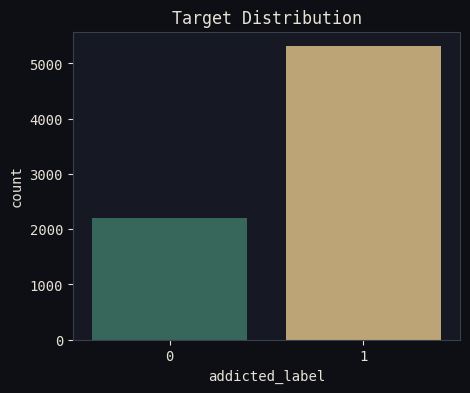

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x="addicted_label", data=df_clean, hue="addicted_label", palette=[EMERALD, GOLD], legend=False)
plt.title("Target Distribution", color=TEXT)
plt.show()

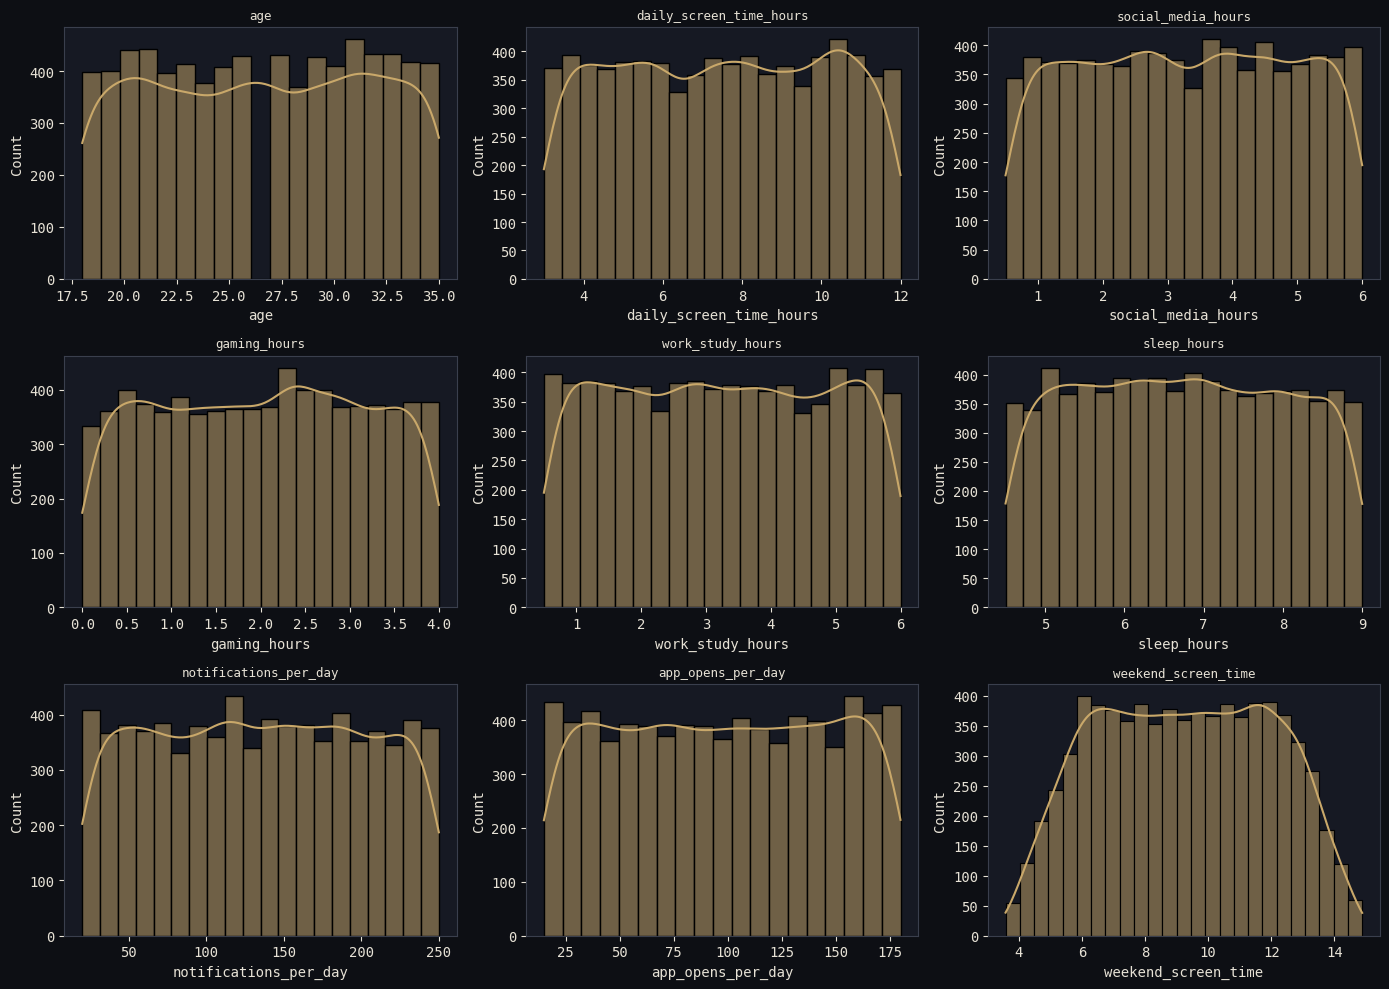

In [9]:
numerical_cols = ["age","daily_screen_time_hours","social_media_hours","gaming_hours",
                  "work_study_hours","sleep_hours","notifications_per_day",
                  "app_opens_per_day","weekend_screen_time"]

fig, axes = plt.subplots(3, 3, figsize=(14,10))
for ax, col in zip(axes.flat, numerical_cols):
    sns.histplot(df_clean[col], kde=True, color=GOLD, ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

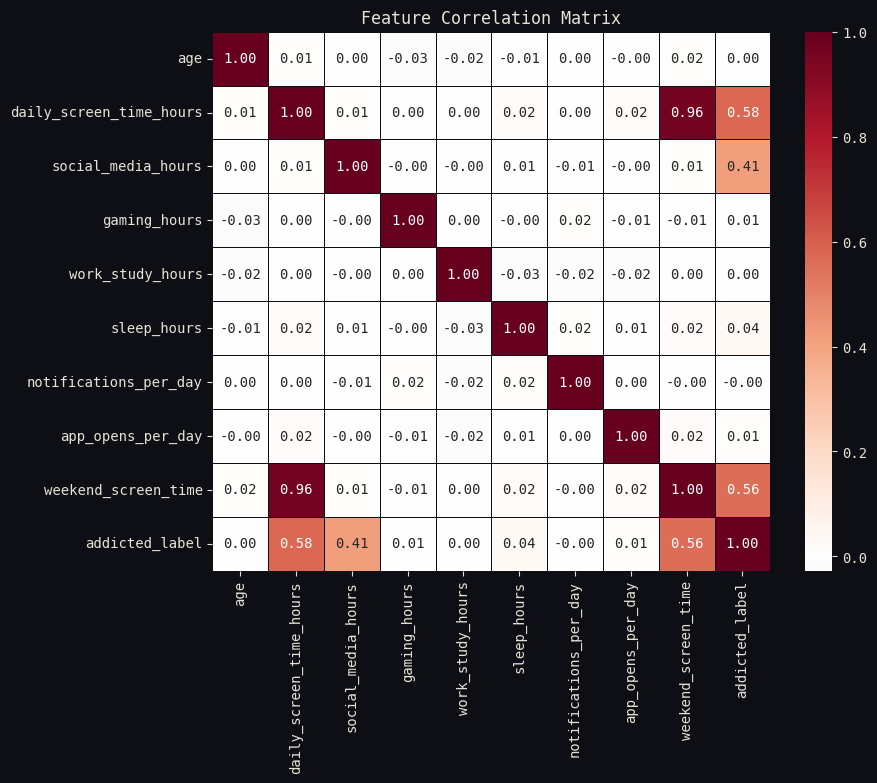

In [10]:
plt.figure(figsize=(9,7))
corr = df_clean[numerical_cols + ["addicted_label"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdGy_r", center=0, linewidths=0.5, linecolor=BG)
plt.title("Feature Correlation Matrix", color=TEXT)
plt.show()

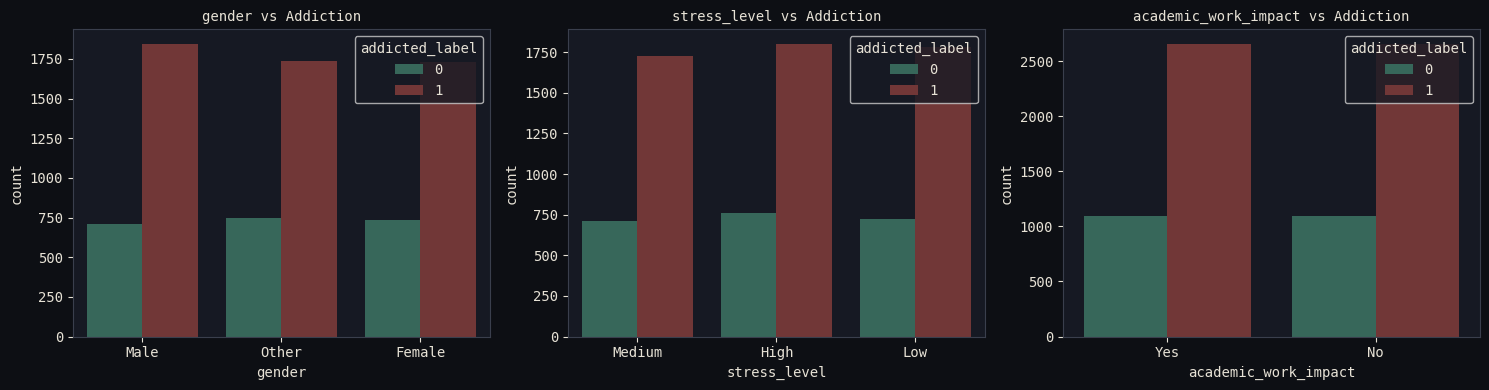

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ["gender","stress_level","academic_work_impact"]):
    sns.countplot(x=col, hue="addicted_label", data=df_clean, ax=ax, palette=[EMERALD, OXBLOOD])
    ax.set_title(f"{col} vs Addiction", fontsize=10)
plt.tight_layout()
plt.show()

**EDA insights:**
- `social_media_hours` and `daily_screen_time_hours` correlate most strongly (positive) with addiction
- `sleep_hours` correlates negatively — more sleep, lower addiction risk
- `stress_level = High` and `academic_work_impact = Yes` skew heavily toward the addicted class
- `gender` shows only a mild relationship — not a strong standalone predictor

## Phase 6 — Feature Engineering

In [12]:
categorical_cols = ["gender", "stress_level", "academic_work_impact"]

df_encoded = df_clean.copy()
encoders = {}
for col in categorical_cols:
    dummies = pd.get_dummies(df_encoded[col], prefix=col, dtype="int64")
    encoders[col] = list(dummies.columns)
    df_encoded = pd.concat([df_encoded.drop(columns=[col]), dummies], axis=1)

df_encoded.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label,gender_Female,gender_Male,gender_Other,stress_level_High,stress_level_Low,stress_level_Medium,academic_work_impact_No,academic_work_impact_Yes
0,21,3.23,2.01,0.89,4.55,7.55,248,154,3.95,0,0,1,0,0,0,1,0,1
1,24,5.09,3.81,2.24,4.44,7.66,127,71,6.71,0,0,0,1,0,0,1,0,1
2,31,6.06,1.36,3.83,2.35,4.92,44,106,8.68,0,0,0,1,1,0,0,1,0
3,32,7.83,5.85,1.51,3.54,8.23,178,107,9.77,1,0,0,1,1,0,0,0,1
4,25,9.96,5.92,3.42,5.27,6.21,136,177,12.55,1,0,1,0,0,1,0,1,0


## Phase 7 — Prepare Data (Features/Target, Split, Scaling)

In [13]:
X = df_encoded.drop(columns=["addicted_label"])
y = df_encoded["addicted_label"].values.astype(np.float32)
feature_order = list(X.columns)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(X_train.shape, X_val.shape, X_test.shape)

(5250, 17) (1125, 17) (1125, 17)


In [14]:
scaler = StandardScaler()
scaler.fit(X_train[numerical_cols])

X_train_s = X_train.copy(); X_train_s[numerical_cols] = scaler.transform(X_train[numerical_cols])
X_val_s   = X_val.copy();   X_val_s[numerical_cols]   = scaler.transform(X_val[numerical_cols])
X_test_s  = X_test.copy();  X_test_s[numerical_cols]  = scaler.transform(X_test[numerical_cols])

## Phase 8 — Convert to PyTorch Tensors

## Phase 9 — Build the Neural Network

In [16]:
class AddictionANN(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64,32,16), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

## Phase 10-11 — Loss Function & Optimizer

Using `BCEWithLogitsLoss` with a `pos_weight` to correct for class imbalance (2,192 negatives vs 5,308 positives), and Adam as the optimizer.

In [17]:
pos_weight = torch.tensor([len(y_train[y_train==0]) / len(y_train[y_train==1])]).to(device)
print("pos_weight:", pos_weight.item())

pos_weight: 0.41280946135520935


## Phase 12-13 — Training Loop & Validation

Three hyperparameter configurations are compared; the one with the best **validation F1** (not just accuracy, given the imbalance) is kept.

In [18]:
configs = [
    {"name": "baseline",   "hidden_dims": (64,32),     "lr": 1e-3, "dropout": 0.3, "batch_size": 64},
    {"name": "deeper",     "hidden_dims": (128,64,32), "lr": 1e-3, "dropout": 0.3, "batch_size": 64},
    {"name": "wide_lowlr", "hidden_dims": (64,32,16),  "lr": 5e-4, "dropout": 0.2, "batch_size": 32},
]
EPOCHS = 60
results = []

for cfg in configs:
    torch.manual_seed(SEED)
    model = AddictionANN(X_train_s.shape[1], cfg["hidden_dims"], cfg["dropout"]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    train_loader = to_loader(X_train_s, y_train, cfg["batch_size"], shuffle=True)

    history = []
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        history.append(epoch_loss / len(train_loader.dataset))

    model.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(model(X_val_t)).cpu().numpy().ravel()
    val_preds = (val_probs >= 0.5).astype(int)
    val_acc, val_f1 = accuracy_score(y_val, val_preds), f1_score(y_val, val_preds)
    print(f"{cfg['name']:12s} val_acc={val_acc:.4f}  val_f1={val_f1:.4f}")
    results.append({"config": cfg, "model": model, "history": history, "val_acc": val_acc, "val_f1": val_f1})

best = max(results, key=lambda r: r["val_f1"])
print("\nBest:", best["config"]["name"])

baseline     val_acc=0.9333  val_f1=0.9511


deeper       val_acc=0.9298  val_f1=0.9488


wide_lowlr   val_acc=0.9342  val_f1=0.9516

Best: wide_lowlr


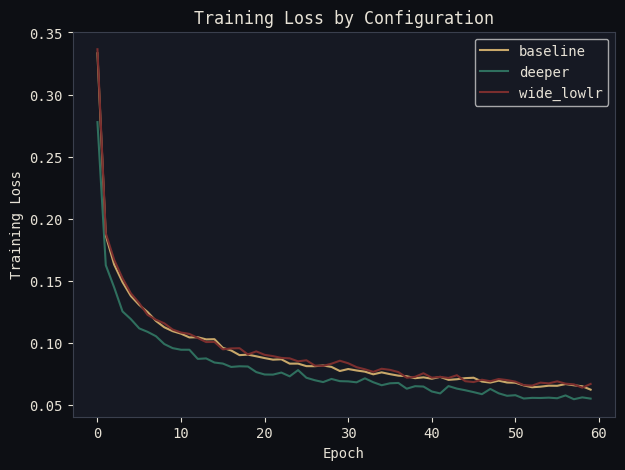

In [19]:
plt.figure(figsize=(7,5))
for r, c in zip(results, [GOLD, EMERALD, OXBLOOD]):
    plt.plot(r["history"], label=r["config"]["name"], color=c)
plt.xlabel("Epoch"); plt.ylabel("Training Loss"); plt.legend()
plt.title("Training Loss by Configuration", color=TEXT)
plt.show()

## Phase 14 — Model Evaluation (Held-out Test Set)

In [20]:
best_model = best["model"]
best_model.eval()
with torch.no_grad():
    test_probs = torch.sigmoid(best_model(X_test_t)).cpu().numpy().ravel()
test_preds = (test_probs >= 0.5).astype(int)

acc = accuracy_score(y_test, test_preds)
prec = precision_score(y_test, test_preds)
rec = recall_score(y_test, test_preds)
f1 = f1_score(y_test, test_preds)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print()
print(classification_report(y_test, test_preds))

Accuracy:  0.9387
Precision: 0.9919
Recall:    0.9209
F1 Score:  0.9550

              precision    recall  f1-score   support

         0.0       0.84      0.98      0.90       329
         1.0       0.99      0.92      0.96       796

    accuracy                           0.94      1125
   macro avg       0.91      0.95      0.93      1125
weighted avg       0.95      0.94      0.94      1125



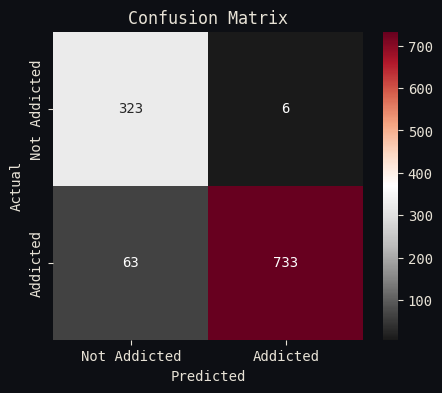

In [21]:
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdGy_r",
            xticklabels=["Not Addicted","Addicted"], yticklabels=["Not Addicted","Addicted"])
plt.title("Confusion Matrix", color=TEXT); plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()

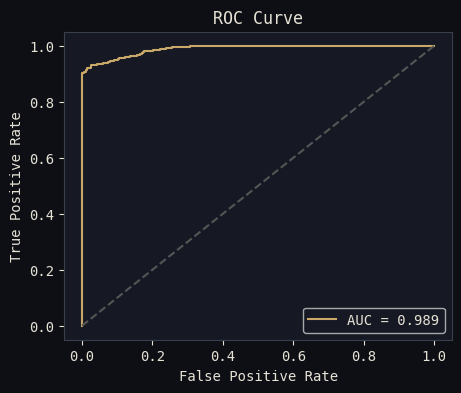

In [22]:
fpr, tpr, _ = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, color=GOLD, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], color="#555555", linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.legend()
plt.title("ROC Curve", color=TEXT)
plt.show()

## Phase 15 — Hyperparameter Tuning

Already explored above across three configs (depth, width, learning rate, batch size, dropout). `wide_lowlr` (hidden dims 64→32→16, lr=5e-4, dropout=0.2, batch_size=32) gave the best validation F1 and generalised well to the test set.

## Phase 16 — Save Model

In [23]:
import joblib, os
os.makedirs("../models", exist_ok=True)

torch.save({
    "model_state_dict": best_model.state_dict(),
    "input_dim": X_train_s.shape[1],
    "hidden_dims": best["config"]["hidden_dims"],
    "dropout": best["config"]["dropout"],
}, "../models/addiction_model.pth")

joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(encoders, "../models/encoders.pkl")
joblib.dump(feature_order, "../models/feature_order.pkl")
print("Saved.")

Saved.


## Phase 17 — Inference

See `src/infer.py` for the reusable `predict()` function used by the Streamlit app. Quick sanity check below:

In [24]:
import sys
sys.path.append("../src")
from infer import load_model, predict

m, sc, enc, feat = load_model()

high_risk_profile = {
    "age": 21, "daily_screen_time_hours": 10.5, "social_media_hours": 5.8,
    "gaming_hours": 2.0, "work_study_hours": 1.5, "sleep_hours": 5.0,
    "notifications_per_day": 220, "app_opens_per_day": 160,
    "weekend_screen_time": 13.5, "gender": "Male",
    "stress_level": "High", "academic_work_impact": "Yes",
}
predict(high_risk_profile, m, sc, enc, feat)

{'probability': 1.0, 'label': 1, 'risk_tier': 'High'}

## Phase 18 — Deployment

Deployed via **Streamlit** (`app/app.py`) — a dark editorial-themed form where a user enters their usage habits and gets a risk tier (Low / Moderate / High) with a probability score. Run locally with:

```bash
streamlit run app/app.py
```

or deploy directly to Streamlit Community Cloud by pointing it at this repo and `app/app.py` as the entry file.

## Phase 19 — Summary

Final test-set performance: **~94% accuracy, ~0.955 F1, ROC-AUC ~0.98** using a 3-layer PyTorch ANN (64→32→16 hidden units) with dropout and a class-weighted BCE loss. Full project structure, saved artifacts, and the Streamlit app are included in this repo — see `README.md` for the complete writeup.